<a href="https://colab.research.google.com/github/LucifersBossyCat/Fitness-Level-Classification-Using-Wearable-Health-Data/blob/main/Machine_Learning_System_for_Fitness_Level_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install missing libraries (safe to run in Colab)
!pip -q install xgboost lightgbm catboost

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    cross_validate,
    GridSearchCV,
    train_test_split
)

from sklearn.preprocessing import (
    StandardScaler,
    label_binarize
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Upload dataset
from google.colab import files

print("Upload hamon_googlefit_medical_realistic.csv")
uploaded = files.upload()

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH  = list(uploaded.keys())[0]
OUTPUT_DIR = './outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_MAP    = {0: 'Low', 1: 'Moderate', 2: 'High'}
CLASS_NAMES  = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
PALETTE      = {'Low': '#4C72B0', 'Moderate': '#DD8452', 'High': '#55A868'}
MODEL_COLORS = ['#7B68EE', '#4C72B0', '#DD8452', '#55A868', '#C44E52']

print('Imports complete')
print(f'Output directory: {os.path.abspath(OUTPUT_DIR)}')

Upload hamon_googlefit_medical_realistic.csv


Saving hamon_googlefit_medical_realistic.csv to hamon_googlefit_medical_realistic (1).csv
Imports complete
Output directory: /content/outputs


In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Shape       : {df.shape[0]:,} rows x {df.shape[1]} cols')

n_users  = df['user_id'].nunique()
rows_pu  = df.groupby('user_id').size()
fl_per_u = df.groupby('user_id')['fitness_level'].nunique()

print(f'Unique users: {n_users:,}  |  rows/user: {rows_pu.min()}-{rows_pu.max()}')
print(f'Users with >1 fitness_level: {(fl_per_u > 1).sum()}')

df.head()

Shape       : 90,000 rows x 37 cols
Unique users: 3,000  |  rows/user: 30-30
Users with >1 fitness_level: 0


,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,date,...,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,sleep_data_available,bp_measured,glucose_measured,cardiometabolic_risk_state
0,1,23,1,30.753735,0,1,1,1.525007,71.532157,2024-01-01,...,36.7,7.58540,0.93389,4,2246,2.6,True,True,False,2
1,1,23,1,30.753735,0,1,1,1.525007,71.499318,2024-01-02,...,36.4,NaN,NaN,3,2497,2.3,False,False,False,2
2,1,23,1,30.753735,0,1,1,1.525007,71.507641,2024-01-03,...,36.7,7.01264,0.91370,5,2648,1.8,True,False,True,2
3,1,23,1,30.753735,0,1,1,1.525007,71.470106,2024-01-04,...,36.6,NaN,NaN,3,2923,2.1,False,False,True,2
4,1,23,1,30.753735,0,1,1,1.525007,71.475484,2024-01-05,...,36.3,NaN,NaN,4,2372,2.8,False,True,False,2


In [6]:
print('Dtypes:')
print(df.dtypes.value_counts())
print('\nMissing values (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))
print('\nClass distribution:')
print(df['fitness_level'].value_counts().rename(LABEL_MAP))

Dtypes:
int64      18
float64    14
bool        3
object      2
Name: count, dtype: int64

Missing values (top 10):
postprandial_glucose    67686
fasting_glucose         67686
bp_systolic             54009
bp_diastolic            54009
sleep_efficiency        22460
sleep_hours             22460
smoking_status              0
sex                         0
age                         0
user_id                     0
dtype: int64

Class distribution:
fitness_level
Moderate    36750
Low         35490
High        17760
Name: count, dtype: int64


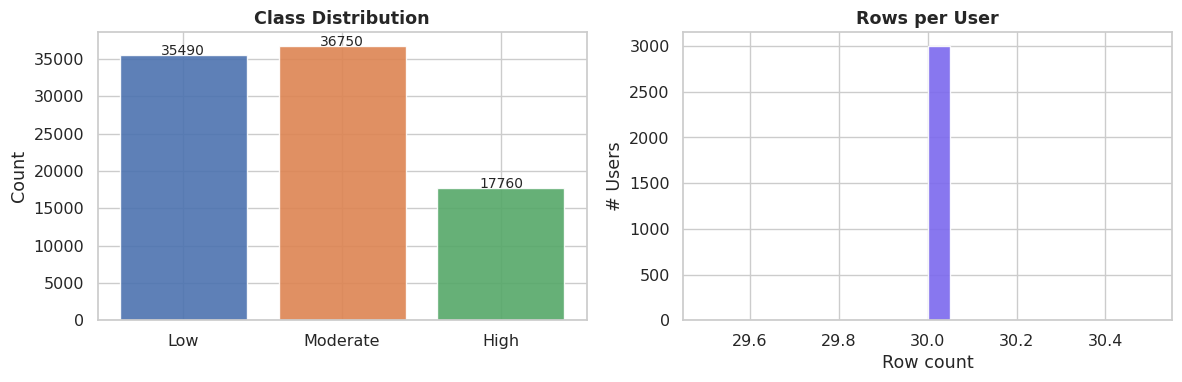

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['fitness_level'].value_counts().sort_index()
axes[0].bar([LABEL_MAP[i] for i in counts.index], counts.values,
            color=list(PALETTE.values()), edgecolor='white', alpha=0.9)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10)

axes[1].hist(rows_pu.values, bins=20, color='#7B68EE', edgecolor='white', alpha=0.9)
axes[1].set_title('Rows per User', fontweight='bold')
axes[1].set_xlabel('Row count')
axes[1].set_ylabel('# Users')

plt.tight_layout()
plt.show()


In [8]:
groups = df['user_id'].values

df_proc = df.drop(columns=['user_id', 'date'])
df_proc = pd.get_dummies(df_proc, columns=['activity_type'], drop_first=False, dtype=int)

for c in ['sleep_data_available', 'bp_measured', 'glucose_measured']:
    df_proc[c] = df_proc[c].astype(int)

X = df_proc.drop(columns=['fitness_level'])
y = df_proc['fitness_level'].values
FEATURE_COLS = X.columns.tolist()

print(f'Feature count : {len(FEATURE_COLS)}')
print(f'Target counts : {dict(pd.Series(y).value_counts().sort_index())}')


Feature count : 40
Target counts : {0: np.int64(35490), 1: np.int64(36750), 2: np.int64(17760)}


In [9]:
user_idx_df = (pd.DataFrame({'user_id': groups,
                                  'fitness_level': y,
                                  'row': np.arange(len(y))})
               .drop_duplicates('user_id')
               .reset_index(drop=True))

train_users_df, test_users_df = train_test_split(
    user_idx_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=user_idx_df['fitness_level'],
)

train_user_set = set(train_users_df['user_id'])
test_user_set  = set(test_users_df['user_id'])

train_mask = np.isin(groups, list(train_user_set))
test_mask  = np.isin(groups, list(test_user_set))

X_train_raw = X[train_mask]
X_test_raw  = X[test_mask]
y_train     = y[train_mask]
y_test      = y[test_mask]
g_train     = groups[train_mask]

overlap = train_user_set & test_user_set
print(f'Train rows : {train_mask.sum():,}  ({len(train_user_set)} users)')
print(f'Test  rows : {test_mask.sum():,}   ({len(test_user_set)} users)')
print(f'User overlap: {len(overlap)}  {"no leakage" if len(overlap) == 0 else "LEAKAGE!"}')

tr_dist = pd.Series(y_train).value_counts(normalize=True).sort_index().round(3)
te_dist = pd.Series(y_test).value_counts(normalize=True).sort_index().round(3)
print(f'Train class % : { {LABEL_MAP[k]: v for k, v in tr_dist.items()} }')
print(f'Test  class % : { {LABEL_MAP[k]: v for k, v in te_dist.items()} }')


Train rows : 72,000  (2400 users)
Test  rows : 18,000   (600 users)
User overlap: 0  no leakage
Train class % : {'Low': 0.394, 'Moderate': 0.408, 'High': 0.198}
Test  class % : {'Low': 0.395, 'Moderate': 0.408, 'High': 0.197}


In [10]:
imputer     = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw),
                            columns=FEATURE_COLS, index=X_train_raw.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_raw),
                            columns=FEATURE_COLS, index=X_test_raw.index)

print(f'Median imputation fitted on training fold only')
print(f'NaN remaining — train: {X_train_imp.isnull().sum().sum()}  '
      f'test: {X_test_imp.isnull().sum().sum()}')


Median imputation fitted on training fold only
NaN remaining — train: 0  test: 0


In [13]:
# Reference stats computed from training data only
train_stats = {
    'steps_max'          : X_train_imp['steps'].max(),
    'heart_points_max'   : X_train_imp['heart_points'].max(),
    'fasting_glucose_med': X_train_imp['fasting_glucose'].median(),
}
print(f'Train-derived stats: {train_stats}')


def engineer_features(dfi: pd.DataFrame, stats: dict) -> pd.DataFrame:
    d = dfi.copy()

    # hp_efficiency — NaN on rest days (move_minutes == 0)
    active = d['move_minutes'] > 0
    d['hp_efficiency'] = np.where(active,
                                   d['heart_points'] / d['move_minutes'],
                                   np.nan)

    # pulse_pressure: elevated >60 mmHg linked to lower cardio fitness
    d['pulse_pressure'] = d['bp_systolic'] - d['bp_diastolic']

    # aerobic_load: weighted composite normalised by training max (ACSM / Swain 2002)
    d['aerobic_load'] = (0.4 * d['steps']       / stats['steps_max'] +
                         0.6 * d['heart_points'] / stats['heart_points_max'])

    # glucose_ratio: postprandial / fasting (>1.4 = impaired tolerance, ADA 2023)
    fg_safe = d['fasting_glucose'].replace(0, np.nan).fillna(stats['fasting_glucose_med'])
    d['glucose_ratio'] = d['postprandial_glucose'] / fg_safe

    # bmi_cat: WHO categories
    d['bmi_cat'] = pd.cut(d['bmi'],
                           bins=[0, 18.5, 24.9, 29.9, np.inf],
                           labels=[0, 1, 2, 3]).astype(float)
    return d


X_train_fe = engineer_features(X_train_imp, train_stats)
X_test_fe  = engineer_features(X_test_imp,  train_stats)

# Check which engineered features contain NaNs
print('\nNaNs after feature engineering:')
print(X_train_fe.isnull().sum()[X_train_fe.isnull().sum() > 0])

# Impute NaNs introduced during feature engineering
post_fe_imputer = SimpleImputer(strategy='median')

X_train_fe = pd.DataFrame(
    post_fe_imputer.fit_transform(X_train_fe),
    columns=X_train_fe.columns,
    index=X_train_fe.index
)

X_test_fe = pd.DataFrame(
    post_fe_imputer.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

FEAT_NAMES = X_train_fe.columns.tolist()

print(f'5 features added — total: {len(FEAT_NAMES)} columns')
X_train_fe[['hp_efficiency', 'pulse_pressure', 'aerobic_load',
             'glucose_ratio', 'bmi_cat']].describe().round(3)



Train-derived stats: {'steps_max': 19742.0, 'heart_points_max': 120.0, 'fasting_glucose_med': 101.0}

NaNs after feature engineering:
hp_efficiency    6063
dtype: int64
5 features added — total: 45 columns


,hp_efficiency,pulse_pressure,aerobic_load,glucose_ratio,bmi_cat
count,72000.000,72000.000,72000.000,72000.000,72000.000
mean,0.980,46.469,0.344,1.373,1.746
std,0.174,4.306,0.216,0.069,0.819
min,0.000,28.000,0.000,1.093,0.000
25%,0.846,46.000,0.176,1.376,1.000
50%,0.989,46.000,0.342,1.376,2.000
75%,1.117,46.000,0.501,1.376,2.000
max,1.299,80.000,0.974,1.819,3.000


Selecting Logistic Regression C via GroupKFold grid search...
Best C = 0.1


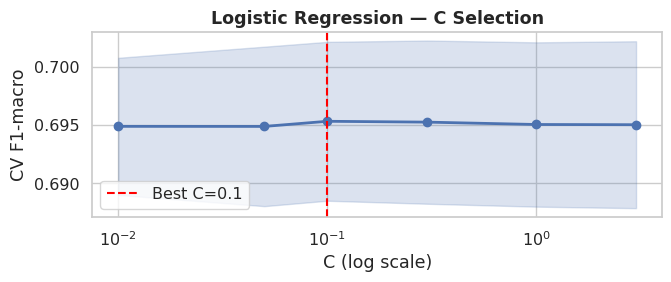

In [14]:
scaler     = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train_fe),
    columns=FEAT_NAMES,
    index=X_train_fe.index
)

X_test_sc  = pd.DataFrame(
    scaler.transform(X_test_fe),
    columns=FEAT_NAMES,
    index=X_test_fe.index
)

SCALE_NEEDED = {'Logistic Regression'}

print('Selecting Logistic Regression C via GroupKFold grid search...')
_lr_grid = LogisticRegression(max_iter=1000, solver='lbfgs',
                               multi_class='multinomial',
                               class_weight='balanced',
                               random_state=RANDOM_STATE)
_gkf_sel = GroupKFold(n_splits=5)
_c_grid  = GridSearchCV(_lr_grid,
                         param_grid={'C': [0.01, 0.05, 0.1, 0.3, 1.0, 3.0]},
                         cv=_gkf_sel, scoring='f1_macro', n_jobs=-1)
_c_grid.fit(X_train_sc, y_train, groups=g_train)

BEST_C = _c_grid.best_params_['C']
print(f'Best C = {BEST_C}')

results_df = pd.DataFrame(_c_grid.cv_results_)
plt.figure(figsize=(7, 3))
plt.semilogx(results_df['param_C'], results_df['mean_test_score'],
             'o-', color='#4C72B0', linewidth=2)
plt.fill_between(results_df['param_C'].astype(float),
                 results_df['mean_test_score'] - results_df['std_test_score'],
                 results_df['mean_test_score'] + results_df['std_test_score'],
                 alpha=0.2, color='#4C72B0')
plt.axvline(BEST_C, color='red', linestyle='--', label=f'Best C={BEST_C}')
plt.xlabel('C (log scale)')
plt.ylabel('CV F1-macro')
plt.title('Logistic Regression — C Selection', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
models = {

    'Logistic Regression': LogisticRegression(
        C=BEST_C, max_iter=1000, solver='lbfgs',
        multi_class='multinomial', class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        min_samples_leaf=20, min_samples_split=40,
        max_features='sqrt', class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    ),

    'XGBoost': XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.7, min_child_weight=10,
        reg_alpha=0.5, reg_lambda=2.0, gamma=0.1,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss', tree_method='hist',
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        num_leaves=20, subsample=0.7, colsample_bytree=0.7,
        min_child_samples=30, reg_alpha=0.5, reg_lambda=2.0,
        class_weight='balanced', n_jobs=-1,
        random_state=RANDOM_STATE, verbose=-1
    ),

    'CatBoost': CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=4, l2_leaf_reg=5.0,
        auto_class_weights='Balanced', eval_metric='TotalF1',
        loss_function='MultiClass',
        random_seed=RANDOM_STATE, verbose=0
    ),
}

print('Models defined:', list(models.keys()))


Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


In [16]:
GKF = GroupKFold(n_splits=5)
cv_results = {}
SCORING = ['accuracy', 'f1_macro']

for name, model in models.items():
    print(f'\n{name} — 5-fold GroupKFold CV...')
    X_cv = X_train_sc if name in SCALE_NEEDED else X_train_fe

    cv = cross_validate(
        model, X_cv, y_train, groups=g_train,
        cv=GKF, scoring=SCORING,
        n_jobs=-1 if name != 'CatBoost' else 1,
        return_train_score=True,
    )
    gap = cv['train_accuracy'].mean() - cv['test_accuracy'].mean()
    cv_results[name] = {
        'cv_acc_mean'   : cv['test_accuracy'].mean(),
        'cv_acc_std'    : cv['test_accuracy'].std(),
        'cv_f1_mean'    : cv['test_f1_macro'].mean(),
        'cv_f1_std'     : cv['test_f1_macro'].std(),
        'train_acc_mean': cv['train_accuracy'].mean(),
        'overfit_gap'   : gap,
        'fold_accs'     : cv['test_accuracy'],
    }
    flag = 'consider tighter regularisation' if gap > 0.08 else 'acceptable'
    print(f'   CV Acc  : {cv["test_accuracy"].mean():.4f} +/- {cv["test_accuracy"].std():.4f}')
    print(f'   CV F1m  : {cv["test_f1_macro"].mean():.4f} +/- {cv["test_f1_macro"].std():.4f}')
    print(f'   Train Acc: {cv["train_accuracy"].mean():.4f}  |  Gap: {gap:.4f}  ({flag})')

print('\nCross-validation complete')



Logistic Regression — 5-fold GroupKFold CV...
   CV Acc  : 0.6978 +/- 0.0054
   CV F1m  : 0.6953 +/- 0.0068
   Train Acc: 0.7021  |  Gap: 0.0043  (acceptable)

Random Forest — 5-fold GroupKFold CV...
   CV Acc  : 0.6994 +/- 0.0043
   CV F1m  : 0.6942 +/- 0.0066
   Train Acc: 0.7523  |  Gap: 0.0530  (acceptable)

XGBoost — 5-fold GroupKFold CV...
   CV Acc  : 0.7283 +/- 0.0027
   CV F1m  : 0.7228 +/- 0.0039
   Train Acc: 0.8473  |  Gap: 0.1190  (consider tighter regularisation)

LightGBM — 5-fold GroupKFold CV...
   CV Acc  : 0.7158 +/- 0.0039
   CV F1m  : 0.7125 +/- 0.0062
   Train Acc: 0.9115  |  Gap: 0.1957  (consider tighter regularisation)

CatBoost — 5-fold GroupKFold CV...
   CV Acc  : 0.7220 +/- 0.0067
   CV F1m  : 0.7186 +/- 0.0094
   Train Acc: 0.7741  |  Gap: 0.0521  (acceptable)

Cross-validation complete


In [17]:
test_results  = {}
fitted_models = {}

for name, model in models.items():
    Xtr = X_train_sc if name in SCALE_NEEDED else X_train_fe
    Xte = X_test_sc  if name in SCALE_NEEDED else X_test_fe

    model.fit(Xtr, y_train)
    fitted_models[name] = model

    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)
    if hasattr(y_pred, 'flatten'):
        y_pred = y_pred.flatten()

    acc       = accuracy_score(y_test, y_pred)
    f1m       = f1_score(y_test, y_pred, average='macro')
    f1w       = f1_score(y_test, y_pred, average='weighted')
    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    test_results[name] = {
        'accuracy'   : acc,
        'f1_macro'   : f1m,
        'f1_weighted': f1w,
        'roc_auc'    : auc_score,
        'y_pred'     : y_pred,
        'y_proba'    : y_proba,
    }

    print(f'\n{name}')
    print(f'   Acc: {acc:.4f}  |  F1-macro: {f1m:.4f}  |  F1-weighted: {f1w:.4f}  |  ROC-AUC: {auc_score:.4f}')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))



Logistic Regression
   Acc: 0.6965  |  F1-macro: 0.6972  |  F1-weighted: 0.6925  |  ROC-AUC: 0.8611
              precision    recall  f1-score   support

         Low     0.7497    0.7906    0.7696      7110
    Moderate     0.6635    0.5596    0.6071      7350
        High     0.6514    0.7918    0.7148      3540

    accuracy                         0.6965     18000
   macro avg     0.6882    0.7140    0.6972     18000
weighted avg     0.6952    0.6965    0.6925     18000


Random Forest
   Acc: 0.7027  |  F1-macro: 0.6991  |  F1-weighted: 0.6949  |  ROC-AUC: 0.8725
              precision    recall  f1-score   support

         Low     0.7140    0.8572    0.7791      7110
    Moderate     0.6953    0.5347    0.6045      7350
        High     0.6881    0.7410    0.7135      3540

    accuracy                         0.7027     18000
   macro avg     0.6992    0.7110    0.6991     18000
weighted avg     0.7013    0.7027    0.6949     18000


XGBoost
   Acc: 0.7318  |  F1-macro: 0.72

In [18]:
rows = []
for name in models:
    rows.append({
        'Model'           : name,
        'CV Acc +/- std'  : f"{cv_results[name]['cv_acc_mean']:.4f} +/- {cv_results[name]['cv_acc_std']:.4f}",
        'CV F1m +/- std'  : f"{cv_results[name]['cv_f1_mean']:.4f} +/- {cv_results[name]['cv_f1_std']:.4f}",
        'Test Acc'        : f"{test_results[name]['accuracy']:.4f}",
        'Test F1-macro'   : f"{test_results[name]['f1_macro']:.4f}",
        'Test F1-weighted': f"{test_results[name]['f1_weighted']:.4f}",
        'Test ROC-AUC'    : f"{test_results[name]['roc_auc']:.4f}",
        'Train-CV Gap'    : f"{cv_results[name]['overfit_gap']:.4f}",
    })

summary = pd.DataFrame(rows).set_index('Model')

best = max(test_results, key=lambda n: test_results[n]['f1_macro'])
print(f'BEST MODEL: {best}')
print(f'   Test Accuracy : {test_results[best]["accuracy"]:.4f}')
print(f'   Test F1-macro : {test_results[best]["f1_macro"]:.4f}')
print(f'   Test ROC-AUC  : {test_results[best]["roc_auc"]:.4f}')

summary


BEST MODEL: XGBoost
   Test Accuracy : 0.7318
   Test F1-macro : 0.7283
   Test ROC-AUC  : 0.8852


,CV Acc +/- std,CV F1m +/- std,Test Acc,Test F1-macro,Test F1-weighted,Test ROC-AUC,Train-CV Gap
Model,,,,,,,
Logistic Regression,0.6978 +/- 0.0054,0.6953 +/- 0.0068,0.6965,0.6972,0.6925,0.8611,0.0043
Random Forest,0.6994 +/- 0.0043,0.6942 +/- 0.0066,0.7027,0.6991,0.6949,0.8725,0.0530
XGBoost,0.7283 +/- 0.0027,0.7228 +/- 0.0039,0.7318,0.7283,0.7301,0.8852,0.1190
LightGBM,0.7158 +/- 0.0039,0.7125 +/- 0.0062,0.7229,0.7216,0.7200,0.8788,0.1957
CatBoost,0.7220 +/- 0.0067,0.7186 +/- 0.0094,0.7236,0.7225,0.7188,0.8867,0.0521


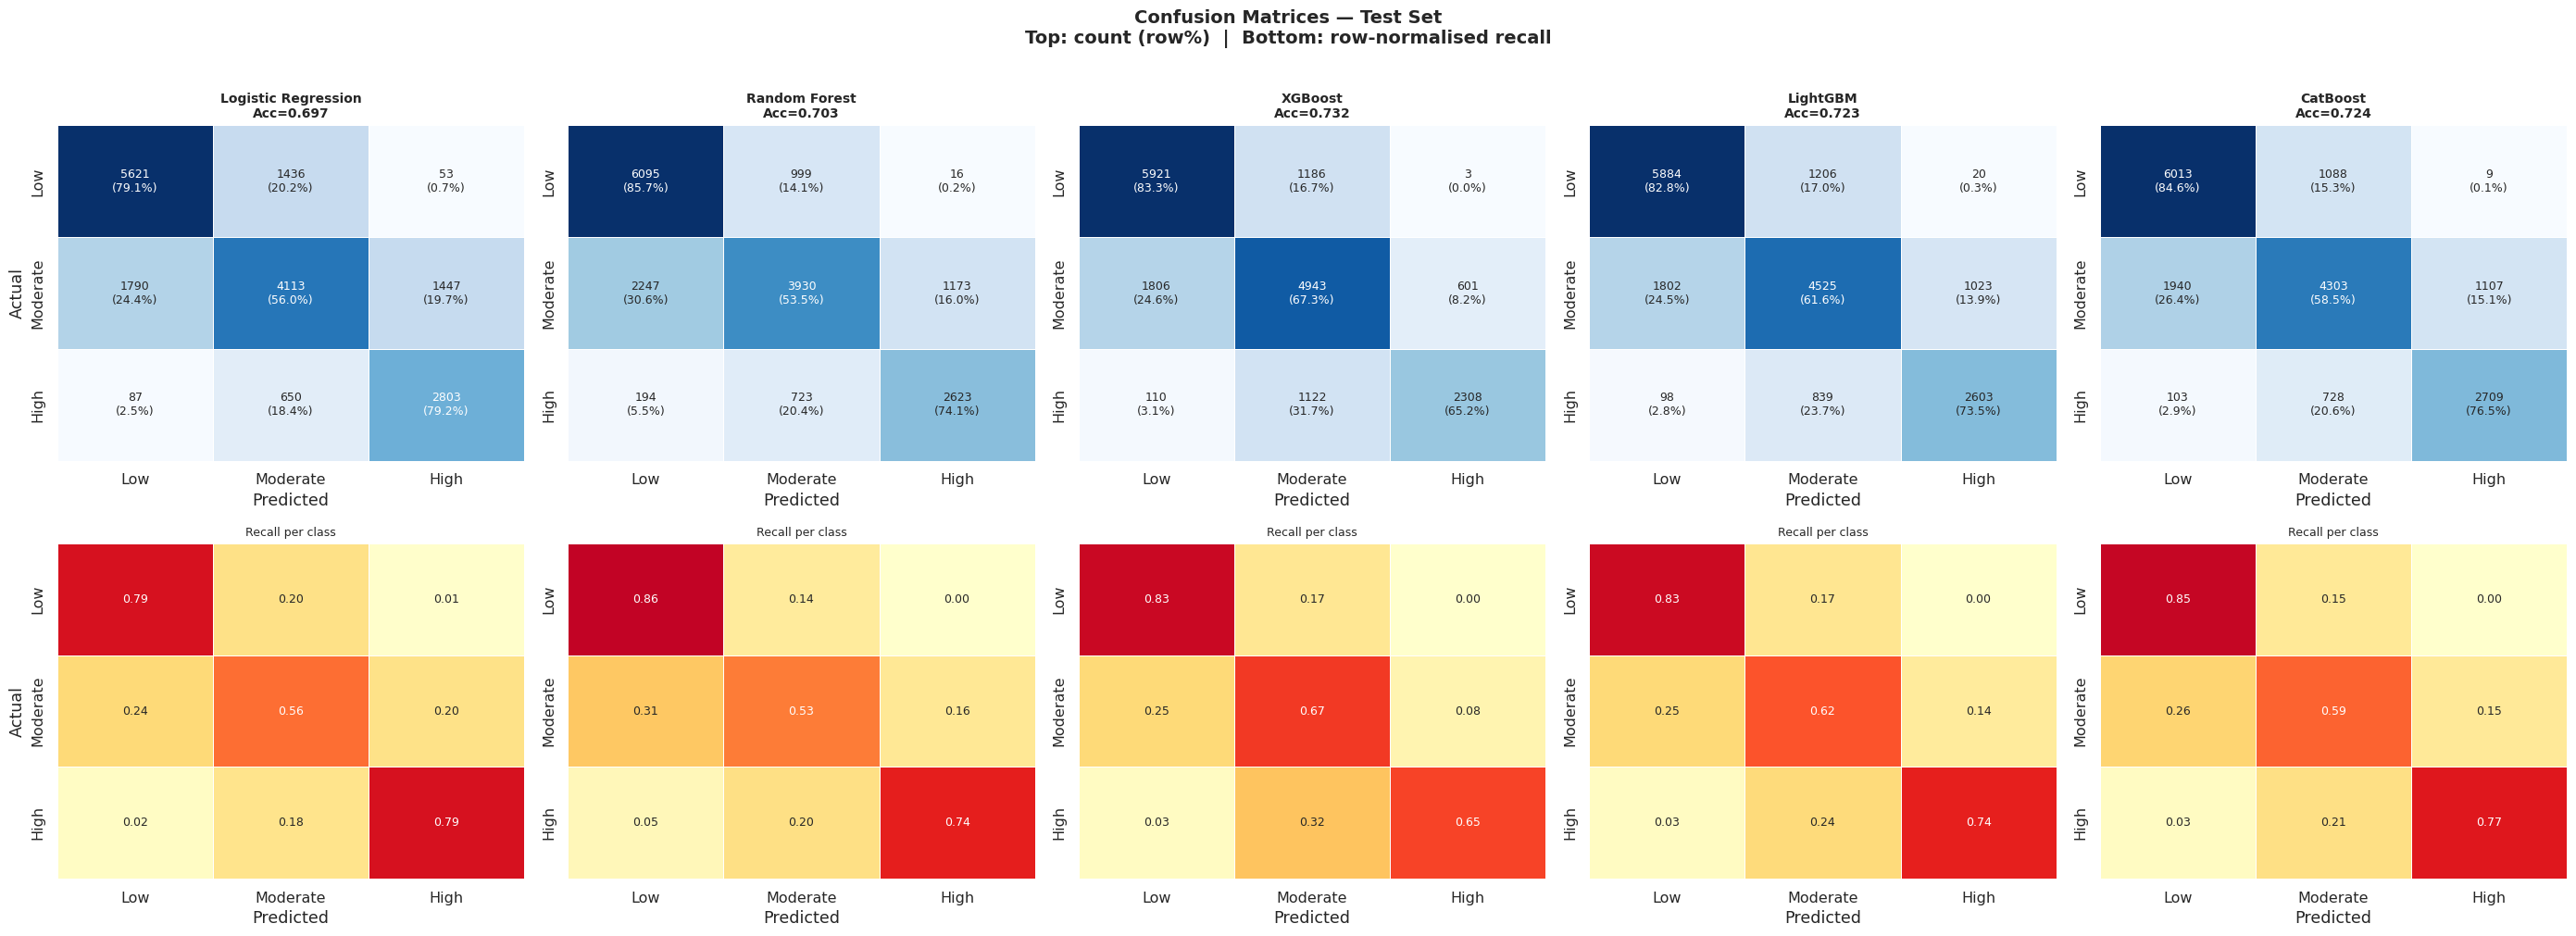

In [19]:
MODEL_ORDER = list(models.keys())
fig, axes = plt.subplots(2, 5, figsize=(28, 10))

for col_i, name in enumerate(MODEL_ORDER):
    y_pred = test_results[name]['y_pred']
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot_raw = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                           for rv, rp in zip(cm, cm_pct)])

    sns.heatmap(cm, annot=annot_raw, fmt='', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=axes[0, col_i], cbar=False,
                annot_kws={'size': 9})
    axes[0, col_i].set_title(f'{name}\nAcc={test_results[name]["accuracy"]:.3f}',
                              fontsize=10, fontweight='bold')
    axes[0, col_i].set_xlabel('Predicted')
    axes[0, col_i].set_ylabel('Actual' if col_i == 0 else '')

    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=axes[1, col_i], vmin=0, vmax=1,
                cbar=False, annot_kws={'size': 9})
    axes[1, col_i].set_title('Recall per class', fontsize=9)
    axes[1, col_i].set_xlabel('Predicted')
    axes[1, col_i].set_ylabel('Actual' if col_i == 0 else '')

fig.suptitle('Confusion Matrices — Test Set\nTop: count (row%)  |  Bottom: row-normalised recall',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()


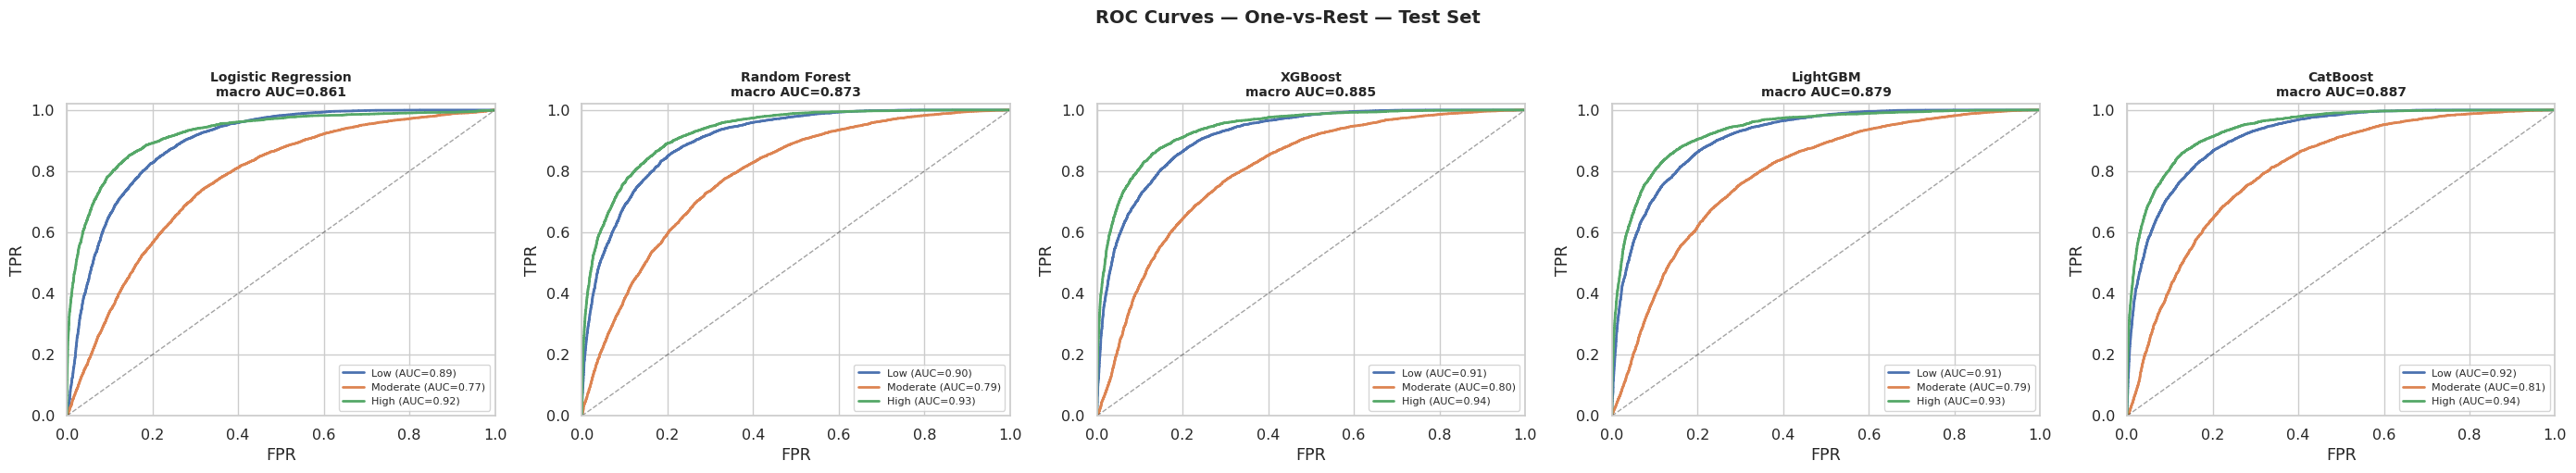

In [20]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, axes  = plt.subplots(1, 5, figsize=(28, 5))

for col_i, (name, color) in enumerate(zip(MODEL_ORDER, MODEL_COLORS)):
    proba = test_results[name]['y_proba']
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], proba[:, cls_idx])
        roc_auc_ = auc(fpr, tpr)
        axes[col_i].plot(fpr, tpr, linewidth=2,
                         label=f'{cls_name} (AUC={roc_auc_:.2f})',
                         color=list(PALETTE.values())[cls_idx])
    axes[col_i].plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
    axes[col_i].set_xlim([0, 1]); axes[col_i].set_ylim([0, 1.02])
    axes[col_i].set_xlabel('FPR'); axes[col_i].set_ylabel('TPR')
    axes[col_i].set_title(f'{name}\nmacro AUC={test_results[name]["roc_auc"]:.3f}',
                           fontsize=10, fontweight='bold')
    axes[col_i].legend(fontsize=8, loc='lower right')

fig.suptitle('ROC Curves — One-vs-Rest — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


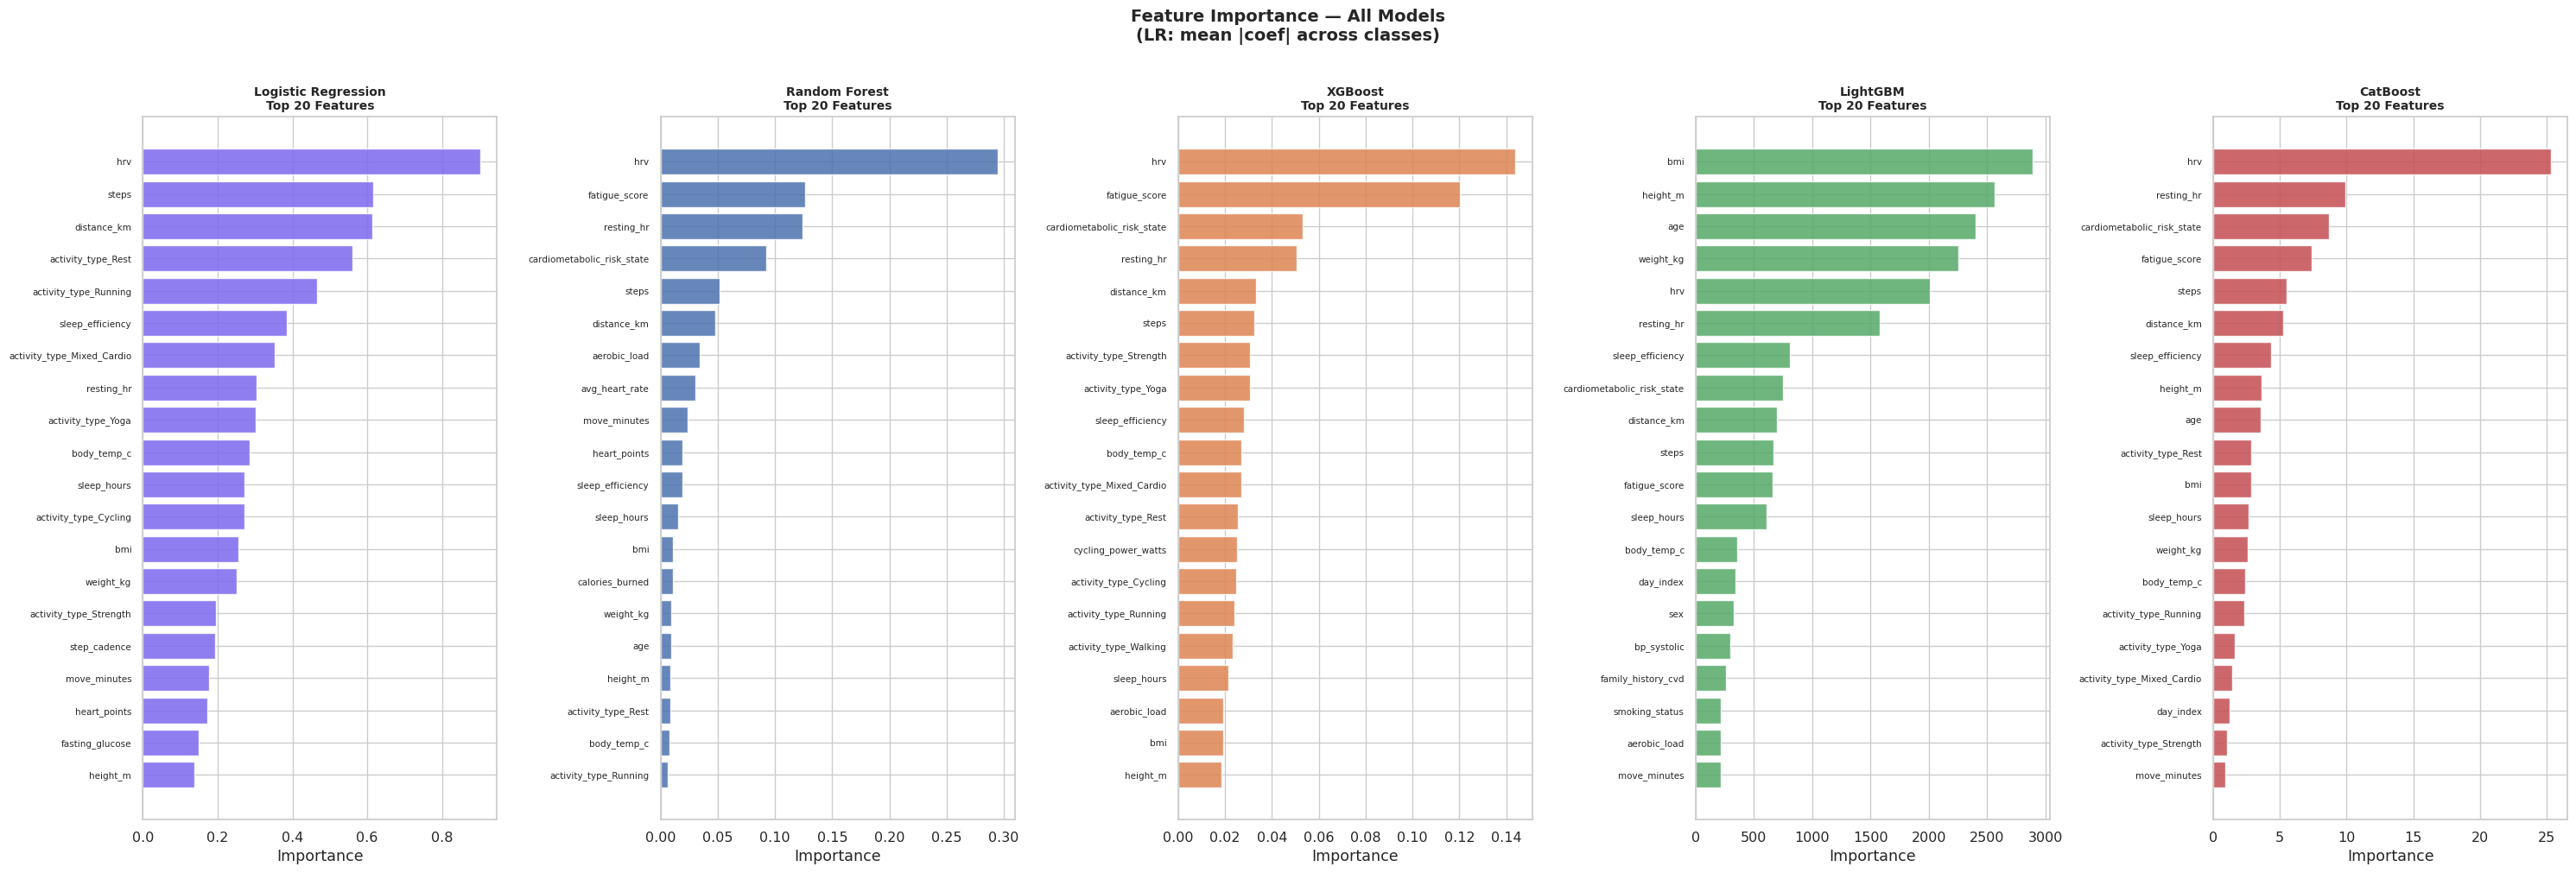

In [21]:
def get_importance(name, model) -> pd.Series:
    if name == 'Logistic Regression':
        return pd.Series(np.abs(model.coef_).mean(axis=0), index=FEAT_NAMES)
    elif name in ('Random Forest', 'XGBoost', 'LightGBM'):
        return pd.Series(model.feature_importances_, index=FEAT_NAMES)
    elif name == 'CatBoost':
        return pd.Series(model.get_feature_importance(), index=FEAT_NAMES)
    return pd.Series(dtype=float)


TOP_N = 20
fig, axes = plt.subplots(1, 5, figsize=(30, 10))
all_importances = {}

for col_i, (name, color) in enumerate(zip(MODEL_ORDER, MODEL_COLORS)):
    imp = get_importance(name, fitted_models[name])
    all_importances[name] = imp
    top = imp.nlargest(TOP_N).sort_values()
    axes[col_i].barh(top.index, top.values, color=color, alpha=0.85, edgecolor='white')
    axes[col_i].set_title(f'{name}\nTop {TOP_N} Features', fontsize=10, fontweight='bold')
    axes[col_i].set_xlabel('Importance')
    axes[col_i].tick_params(axis='y', labelsize=7.5)

fig.suptitle('Feature Importance — All Models\n(LR: mean |coef| across classes)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


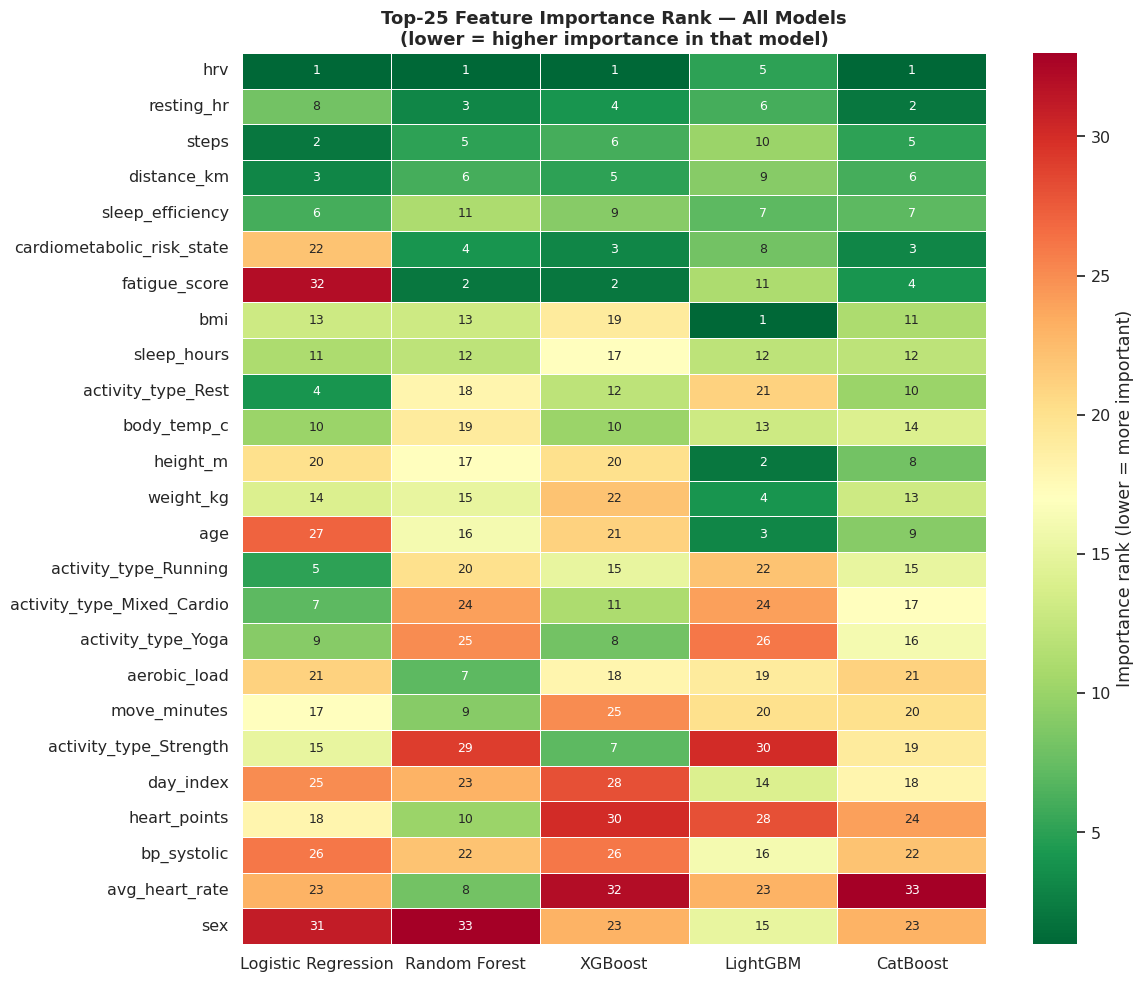

In [22]:
imp_matrix  = pd.DataFrame({name: imp.abs().fillna(0) for name, imp in all_importances.items()})
rank_matrix = imp_matrix.rank(ascending=False)
rank_matrix['avg_rank'] = rank_matrix.mean(axis=1)
top25 = rank_matrix.sort_values('avg_rank').head(25).drop(columns='avg_rank')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(top25, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Importance rank (lower = more important)'},
            annot_kws={'size': 9})
ax.set_title('Top-25 Feature Importance Rank — All Models\n'
             '(lower = higher importance in that model)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'feature_rank_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


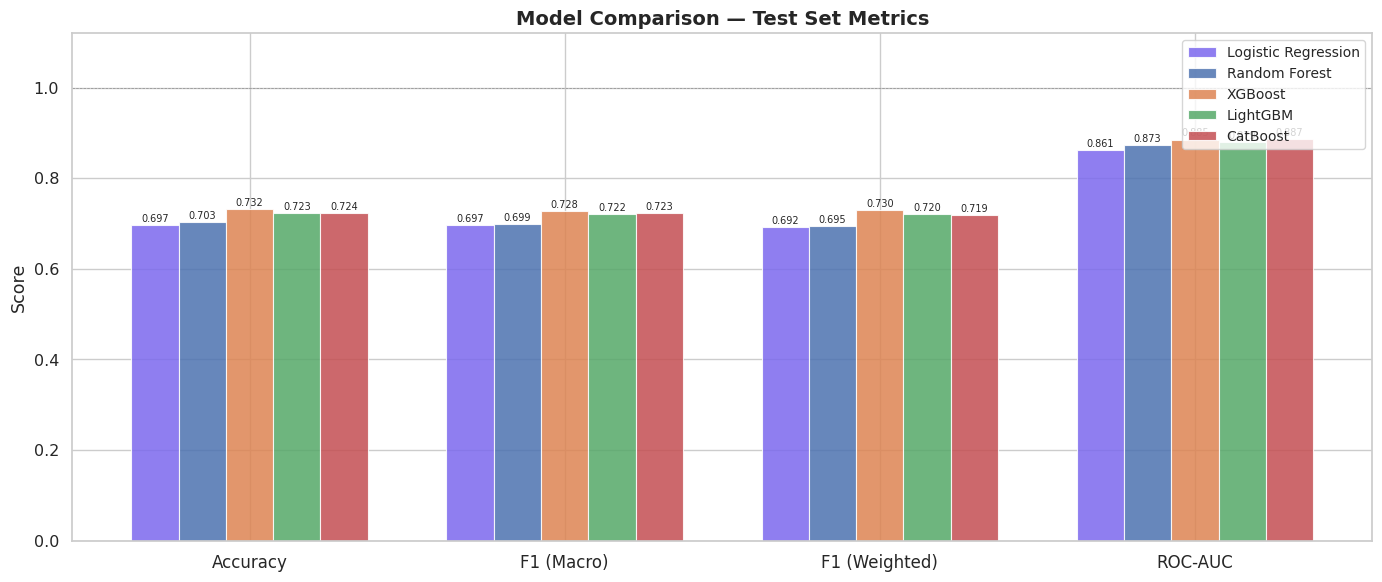

In [23]:
metrics       = ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']
metric_labels = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'ROC-AUC']

fig, ax  = plt.subplots(figsize=(14, 6))
x        = np.arange(len(metrics))
n_models = len(MODEL_ORDER)
width    = 0.15
offsets  = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for i, (name, color) in enumerate(zip(MODEL_ORDER, MODEL_COLORS)):
    vals = [test_results[name][m] for m in metrics]
    bars = ax.bar(x + offsets[i], vals, width, label=name,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.axhline(1.0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


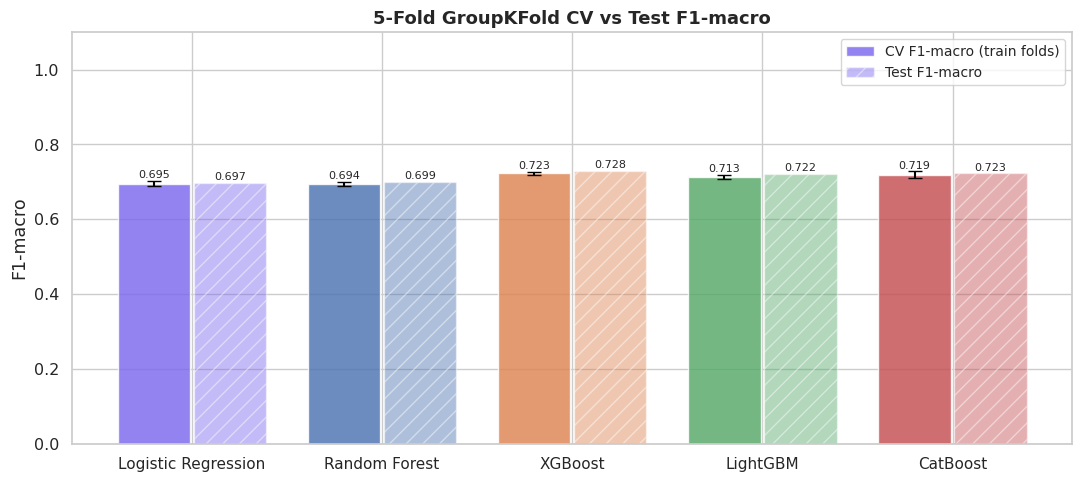

In [24]:
fig, ax  = plt.subplots(figsize=(11, 5))
x        = np.arange(n_models)
cv_means = [cv_results[n]['cv_f1_mean'] for n in MODEL_ORDER]
cv_stds  = [cv_results[n]['cv_f1_std']  for n in MODEL_ORDER]
test_f1s = [test_results[n]['f1_macro'] for n in MODEL_ORDER]

ax.bar(x - 0.2, cv_means, 0.38,
       color=MODEL_COLORS[:n_models], alpha=0.82,
       edgecolor='white', label='CV F1-macro (train folds)')
ax.errorbar(x - 0.2, cv_means, yerr=cv_stds,
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.bar(x + 0.2, test_f1s, 0.38,
       color=MODEL_COLORS[:n_models], alpha=0.45,
       edgecolor='white', hatch='//', label='Test F1-macro')

for i, (cv_m, te_m, cv_s) in enumerate(zip(cv_means, test_f1s, cv_stds)):
    ax.text(i - 0.2, cv_m + cv_s + 0.008, f'{cv_m:.3f}', ha='center', fontsize=8)
    ax.text(i + 0.2, te_m + 0.008,         f'{te_m:.3f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-macro')
ax.set_title('5-Fold GroupKFold CV vs Test F1-macro', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'cv_vs_test.png'), dpi=150, bbox_inches='tight')
plt.show()


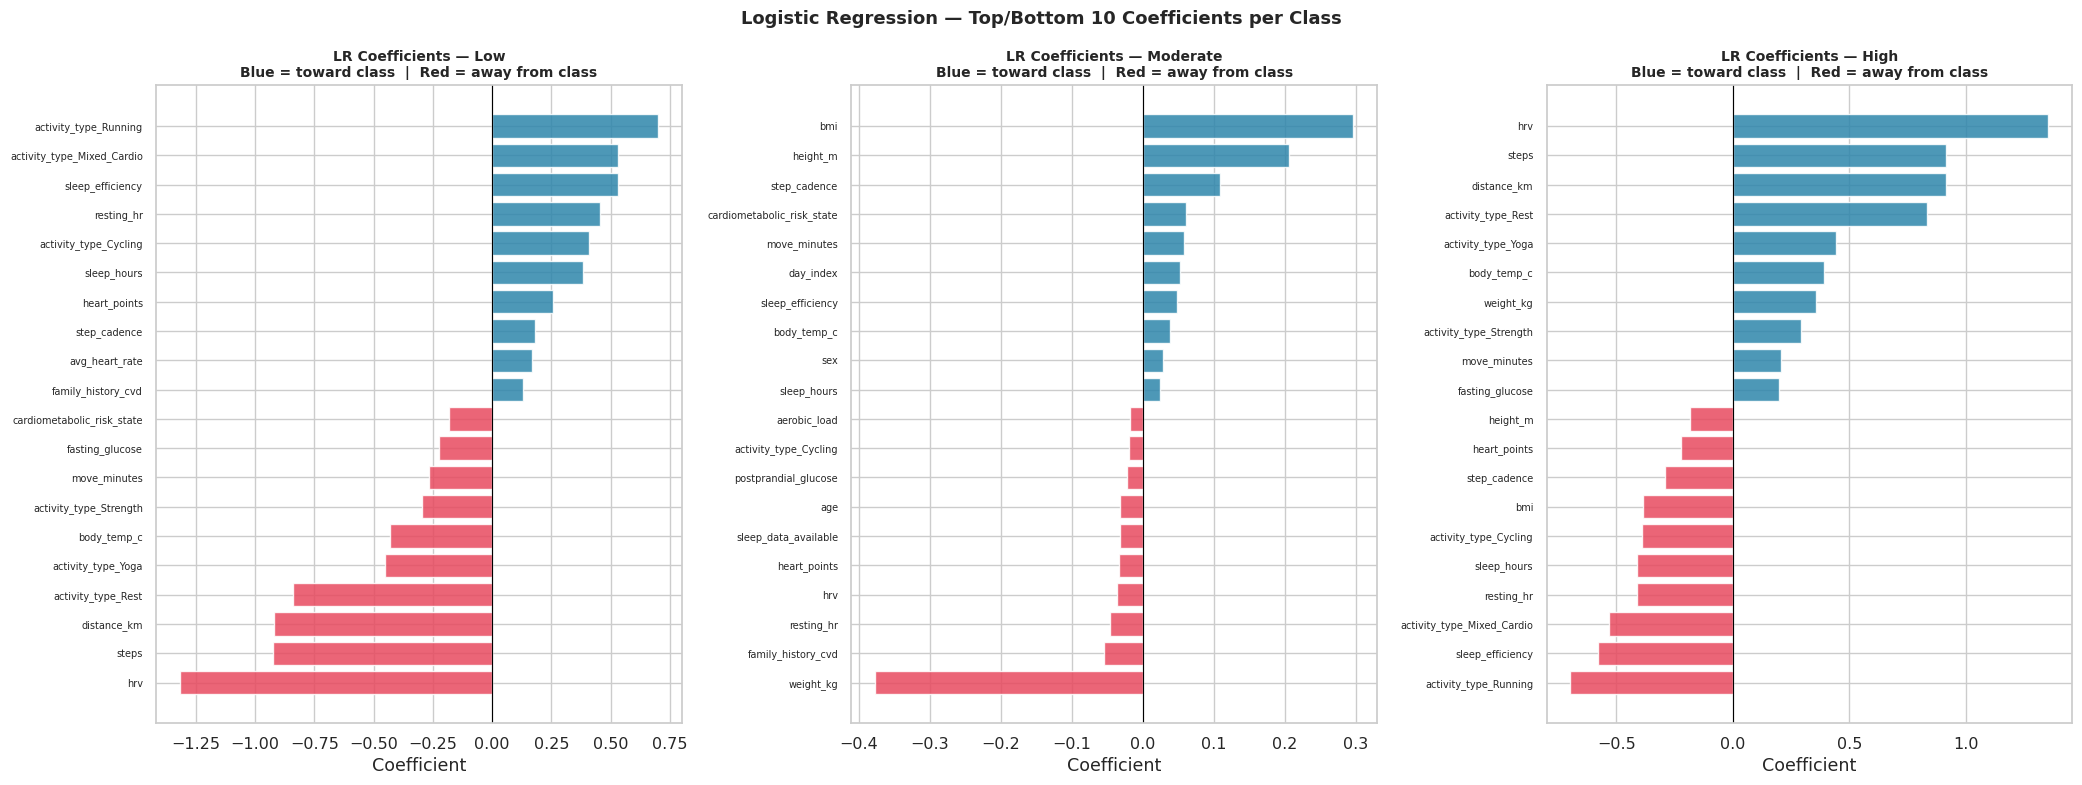

All figures saved to ./outputs/


In [25]:
lr_model = fitted_models['Logistic Regression']
coef_df  = pd.DataFrame(lr_model.coef_.T, index=FEAT_NAMES, columns=CLASS_NAMES)

fig, axes = plt.subplots(1, 3, figsize=(21, 8))
for ax, cls_name in zip(axes, CLASS_NAMES):
    coefs = coef_df[cls_name].sort_values()
    top   = pd.concat([coefs.head(10), coefs.tail(10)])
    colors = ['#E84A5F' if v < 0 else '#2E86AB' for v in top.values]
    ax.barh(top.index, top.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LR Coefficients — {cls_name}\nBlue = toward class  |  Red = away from class',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Coefficient')
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Logistic Regression — Top/Bottom 10 Coefficients per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'lr_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()
print('All figures saved to', OUTPUT_DIR)
